<a href="https://colab.research.google.com/github/samiasondha/FTI-finance-research/blob/main/Samia_Sondha_FTI_reserach_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
from scipy.stats import f_oneway

In [45]:
df = pd.read_csv("lendingclub_loans_clean.csv")
df.head()

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,0,...,C3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,0,...,C1,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,0,...,D1,<bound method PandasDelegate._add_delegate_acc...,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,0,...,A3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,37.66,0,...,C3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [46]:
# rename unnamed to borrowers
df['public_record_bankrupt']

,public_record_bankrupt
0,0
1,1
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


**Find data types:**

In [47]:
df.dtypes

,0
Unnamed: 0,int64
emp_title,object
emp_length,float64
state,object
homeownership,object
annual_income,float64
verified_income,object
debt_to_income,float64
debt_to_income_joint,float64
delinq_2y,int64


**find variables and possible nulls:**

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   debt_to_income_joint              1495 non-null   float64
 9   delinq_2y                         10000 non-null  int64  
 10  months_since_last_delinq          4342 non-null   float64
 11  earliest_credit_line              10000 non-null  int64  
 12  inqui

In [49]:
df['annual_income'].mean()

np.float64(79222.148412)

In [50]:
df = df.drop_duplicates()
df[df.duplicated()]

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees


In [51]:
df.isna()

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
# get rid of uneccary columns that have too many nulls
df.drop(['debt_to_income_joint'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   delinq_2y                         10000 non-null  int64  
 9   months_since_last_delinq          4342 non-null   float64
 10  earliest_credit_line              10000 non-null  int64  
 11  inquiries_last_12m                10000 non-null  int64  
 12  total

In [53]:
df['emp_title'] = df['emp_title'].fillna('unknown')

# fill unknown employees with unknown, will be easier to asses than a null

In [54]:
df['emp_length'] = df['emp_length'].fillna('unknown')

In [55]:
df['emp_title']

,emp_title
0,global config engineer
1,warehouse office clerk
2,assembly
3,customer service
4,security supervisor
...,...
9995,owner
9996,director
9997,toolmaker
9998,manager


In [56]:
median_income = df['annual_income'].median()
df['annual_income'] = df['annual_income'].fillna(median_income)

df['annual_income']

# Replace nulls with the median income for now so that we can use this data to make plots

,annual_income
0,90000.0
1,40000.0
2,40000.0
3,30000.0
4,35000.0
...,...
9995,108000.0
9996,121000.0
9997,67000.0
9998,80000.0


In [57]:
median_debt = df['debt_to_income'].median()
df['debt_to_income'] = df['debt_to_income'].fillna(median_income)

df['debt_to_income']

,debt_to_income
0,18.01
1,5.04
2,21.15
3,10.16
4,57.96
...,...
9995,22.28
9996,32.38
9997,45.26
9998,11.99


In [58]:
max_delinq = df['months_since_last_delinq'].max()
df['months_since_last_delinq'] = df['months_since_last_delinq'].fillna(max_delinq)

df['months_since_last_delinq']

,months_since_last_delinq
0,38.0
1,118.0
2,28.0
3,118.0
4,118.0
...,...
9995,118.0
9996,9.0
9997,6.0
9998,118.0


In [59]:
max_90 = df['months_since_90d_late'].max()
df['months_since_90d_late'] = df['months_since_90d_late'].fillna(max_delinq)

df['months_since_90d_late']

,months_since_90d_late
0,38.0
1,118.0
2,28.0
3,118.0
4,118.0
...,...
9995,118.0
9996,9.0
9997,118.0
9998,118.0


In [60]:
max_inquiry = df['months_since_last_credit_inquiry'].max()
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(max_delinq)

df['months_since_last_credit_inquiry']

,months_since_last_credit_inquiry
0,5.0
1,8.0
2,7.0
3,15.0
4,4.0
...,...
9995,6.0
9996,1.0
9997,16.0
9998,5.0


In [61]:
past_due = df['num_accounts_120d_past_due'].max()
df['num_accounts_120d_past_due'] = df['num_accounts_120d_past_due'].fillna('0')

df['num_accounts_120d_past_due']

,num_accounts_120d_past_due
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
9995,0.0
9996,0.0
9997,0.0
9998,0.0


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         10000 non-null  object 
 2   emp_length                        10000 non-null  object 
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    10000 non-null  float64
 8   delinq_2y                         10000 non-null  int64  
 9   months_since_last_delinq          10000 non-null  float64
 10  earliest_credit_line              10000 non-null  int64  
 11  inquiries_last_12m                10000 non-null  int64  
 12  total

In [63]:
df.isna().sum()

,0
Unnamed: 0,0
emp_title,0
emp_length,0
state,0
homeownership,0
annual_income,0
verified_income,0
debt_to_income,0
delinq_2y,0
months_since_last_delinq,0


In [64]:
!pip install matplotlib
import matplotlib.pyplot as plt

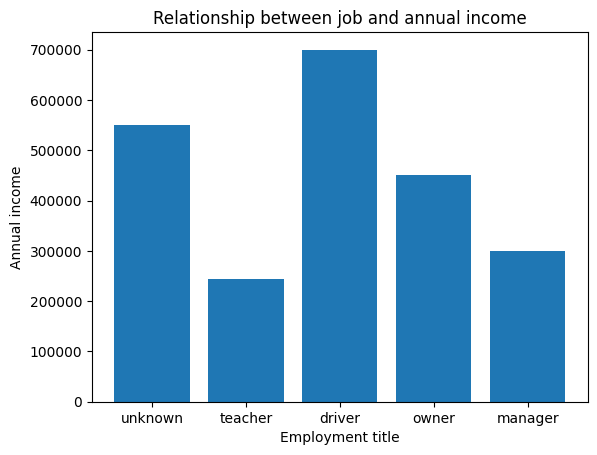

In [65]:
top_10_titles = df['emp_title'].value_counts().head(5).index
df_filtered = df[df['emp_title'].isin(top_10_titles)]
plt.bar(df_filtered['emp_title'], df_filtered['annual_income'])

plt.title('Relationship between job and annual income')
plt.xlabel('Employment title')
plt.ylabel('Annual income')

plt.show()

# this can connect to loans taken for these job titles

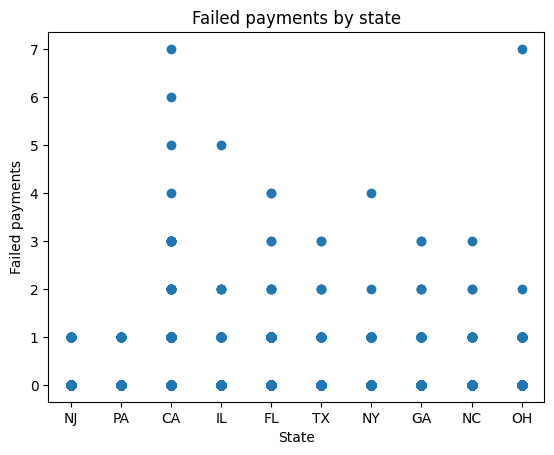

In [66]:
# historical failed to pay & state correlation to see debt by state
top_10_titles = df['state'].value_counts().head(10).index
df_filtered = df[df['state'].isin(top_10_titles)]
plt.scatter(df_filtered['state'], df_filtered['num_historical_failed_to_pay'])

plt.title('Failed payments by state')
plt.xlabel('State')
plt.ylabel('Failed payments')

plt.show()

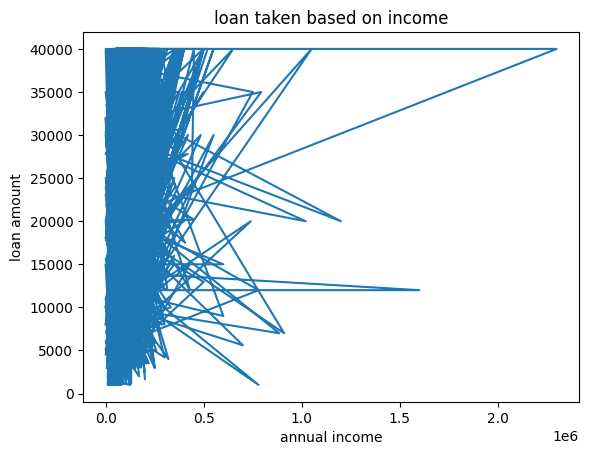

In [67]:
# do people with higher incomes take bigger loans?
plt.plot(df['annual_income'], df['loan_amount'])

plt.title('loan taken based on income')
plt.xlabel('annual income')
plt.ylabel('loan amount')

plt.show()

# this one looks crazy too

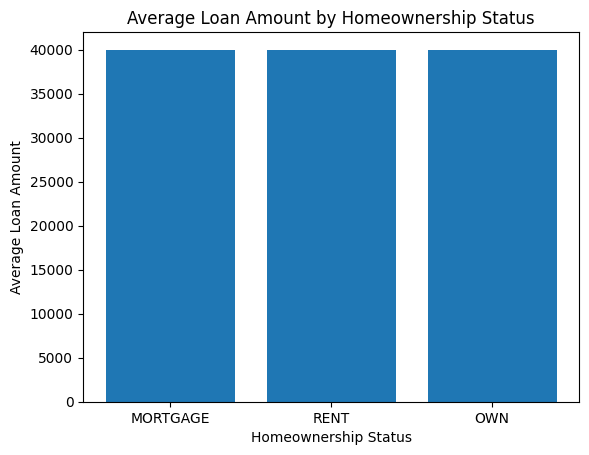

In [68]:
# which type of homeowners take the greatest loans,
plt.bar(df['homeownership'], df['loan_amount'])

plt.title('Average Loan Amount by Homeownership Status')
plt.xlabel('Homeownership Status')
plt.ylabel('Average Loan Amount')
plt.show()

# can search if these homeowners have bad debt as well

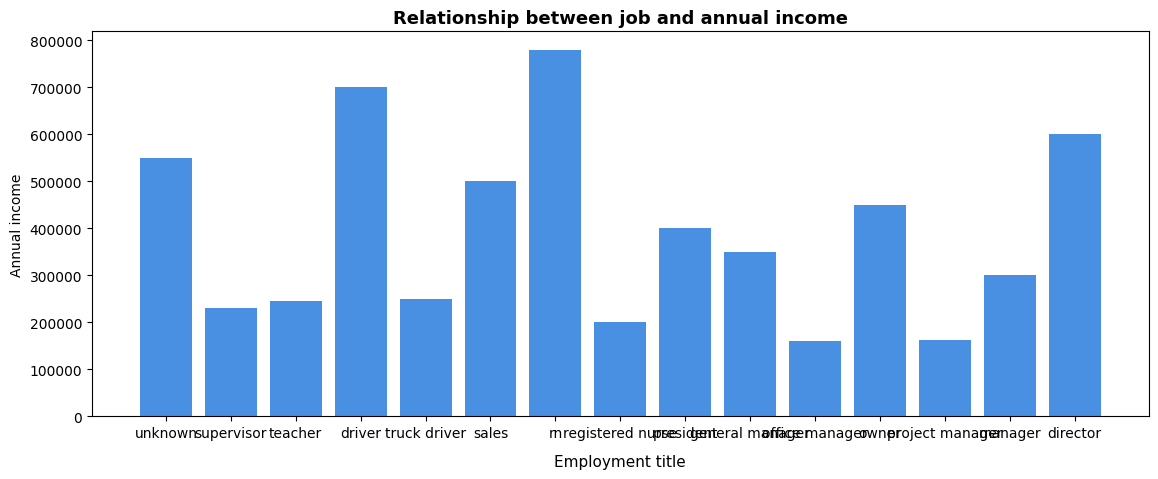

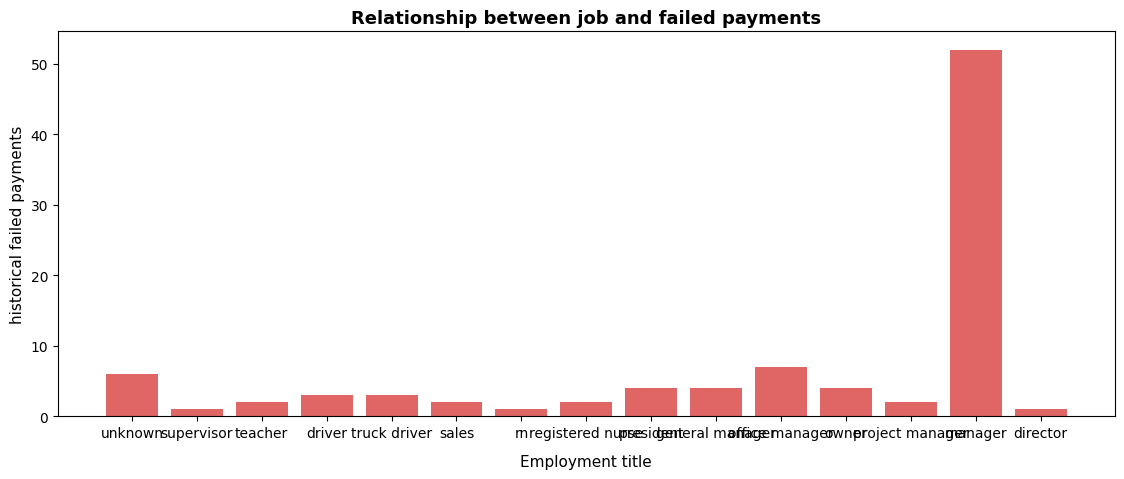

In [69]:
top_10_titles = df['emp_title'].value_counts().head(15).index
df_filtered = df[df['emp_title'].isin(top_10_titles)]
plt.figure(figsize=(30, 5))
plt.subplot(1,2,1)
plt.bar(df_filtered['emp_title'], df_filtered['annual_income'], color='#4a90e2')

plt.title('Relationship between job and annual income', fontsize=13, fontweight='bold')
plt.xlabel('Employment title', fontsize=11, labelpad=10)
plt.ylabel('Annual income', fontsize=10)

plt.figure(figsize=(30, 5))
plt.subplot(1,2,2)
plt.bar(df_filtered['emp_title'], df_filtered['num_historical_failed_to_pay'], color='#e06666')

plt.title('Relationship between job and failed payments', fontsize=13, fontweight='bold')
plt.xlabel('Employment title', fontsize=11, labelpad=10)
plt.ylabel('historical failed payments', fontsize=11)

plt.show()

In [70]:
# hypothesis testing

H₀ = Mean annual income is the same across all occupations

H₁ = At least one ccupaoccupationtoccupationion has a different mean annual income

In [71]:
df['emp_title']
groups = [group["annual_income"].values for _, group in df.groupby("emp_title")]

# Perform ANOVA test
F_stat, p_value = f_oneway(*groups)

print("F-statistic:", F_stat)
print("P-value:", p_value)





F-statistic: 1.3654689095502124
P-value: 1.8057050488095026e-28


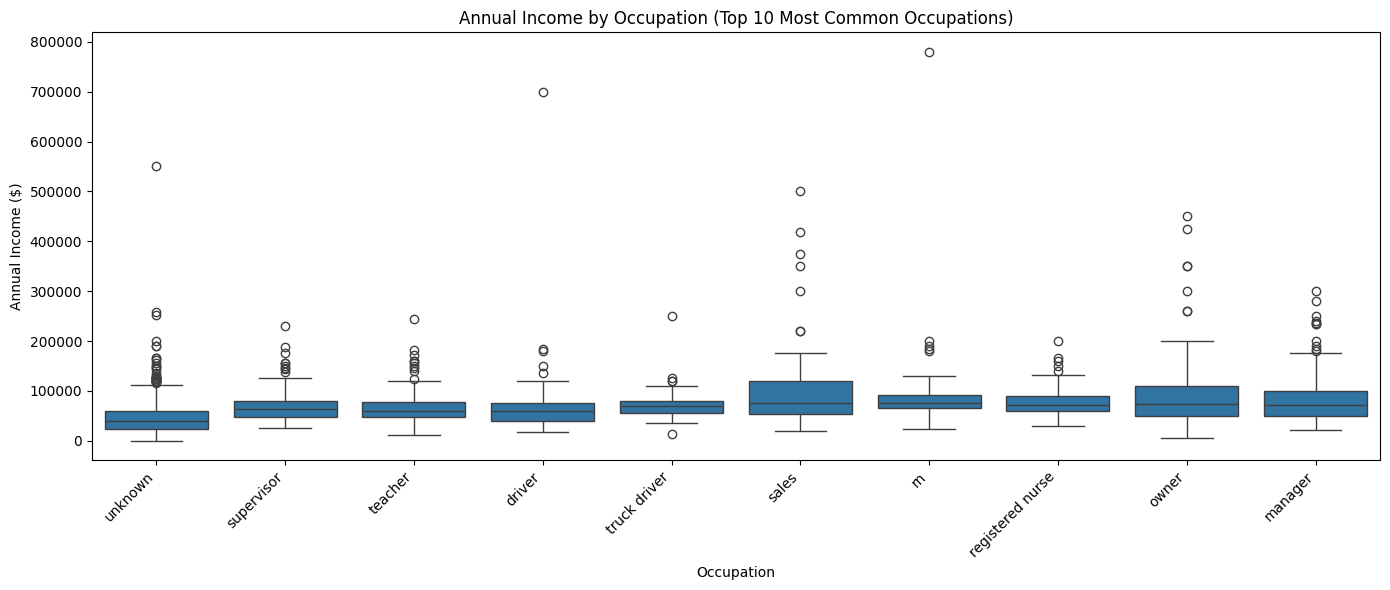

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 most common occupations
top_jobs = df['emp_title'].value_counts().head(10).index

plot_df = df[df['emp_title'].isin(top_jobs)]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=plot_df,
    x='emp_title',
    y='annual_income'
)

plt.xticks(rotation=45, ha='right')
plt.title('Annual Income by Occupation (Top 10 Most Common Occupations)')
plt.xlabel('Occupation')
plt.ylabel('Annual Income ($)')

plt.tight_layout()
plt.show()

We reject the null hypothesis, and average income does differ amongst some job occupations

In [73]:
!pip install scikit-learn

import sklearn

from sklearn.model_selection import train_test_split

from sklearn.metrics import *

In [74]:
features = df[['debt_to_income']]
labels = df['num_historical_failed_to_pay']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2)

In [76]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [77]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

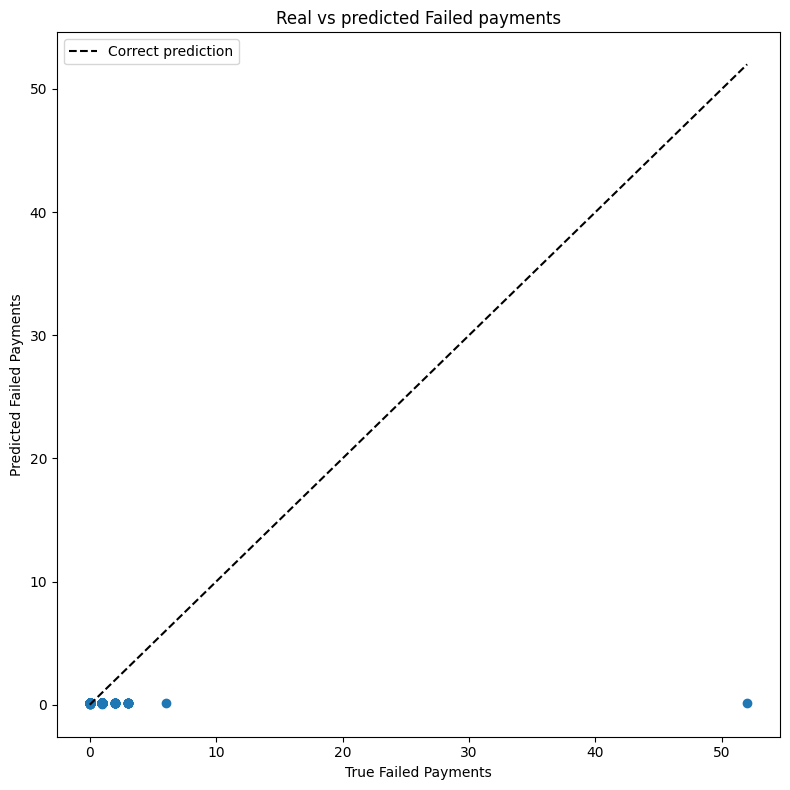

In [78]:
import numpy as np

plt.figure(figsize=(8, 8))

# Calculate MIN_VALUE and MAX_VALUE based on the actual and predicted data
MIN_VALUE = min(y_test.min(), pred.min())
MAX_VALUE = max(y_test.max(), pred.max())

plt.scatter(y_test, pred)
plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")


plt.axis('tight')


plt.xlabel('True Failed Payments')
plt.ylabel('Predicted Failed Payments')
plt.title("Real vs predicted Failed payments")

plt.legend()
plt.tight_layout()

In [79]:
# do borrowers who default have higher debt-to-income ratios than borrowers who repay their loans?
# null hypothesis; the mean debt-to-income is the same, alternative; the mean debt-to-income is not the same


print(df['loan_status'].unique())
from scipy.stats import ttest_ind


['Current' 'Fully Paid' 'In Grace Period' 'Late (31-120 days)'
 'Charged Off' 'Late (16-30 days)']


In [80]:
completed = df[df['loan_status'].isin(["Fully Paid", "Charged Off"])]

fully_paid = completed[completed["loan_status"] == "Fully Paid"]["debt_to_income"]
charged_off = completed[completed["loan_status"] == "Charged Off"]["debt_to_income"]

t_stat, p_value = ttest_ind(
    fully_paid,
    charged_off,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# we cannot reject the null hypothesis,a sort of limitation as this dataset does not show any relation between these

t-statistic: 1.4107493156756903
p-value: 0.15901506663864926


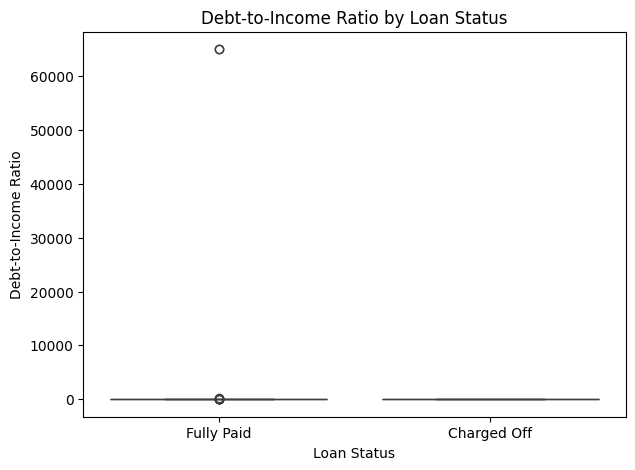

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.boxplot(
    data=completed,
    x="loan_status",
    y="debt_to_income"
)

plt.title("Debt-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

In [82]:
df['loan_purpose']
groups = [group["loan_amount"].values for _, group in df.groupby("loan_purpose")]

# Perform ANOVA test
F_stat, p_value = f_oneway(*groups)

print("F-statistic:", F_stat)
print("P-value:", p_value)

F-statistic: 36.10233579861125
P-value: 9.816214856332122e-77


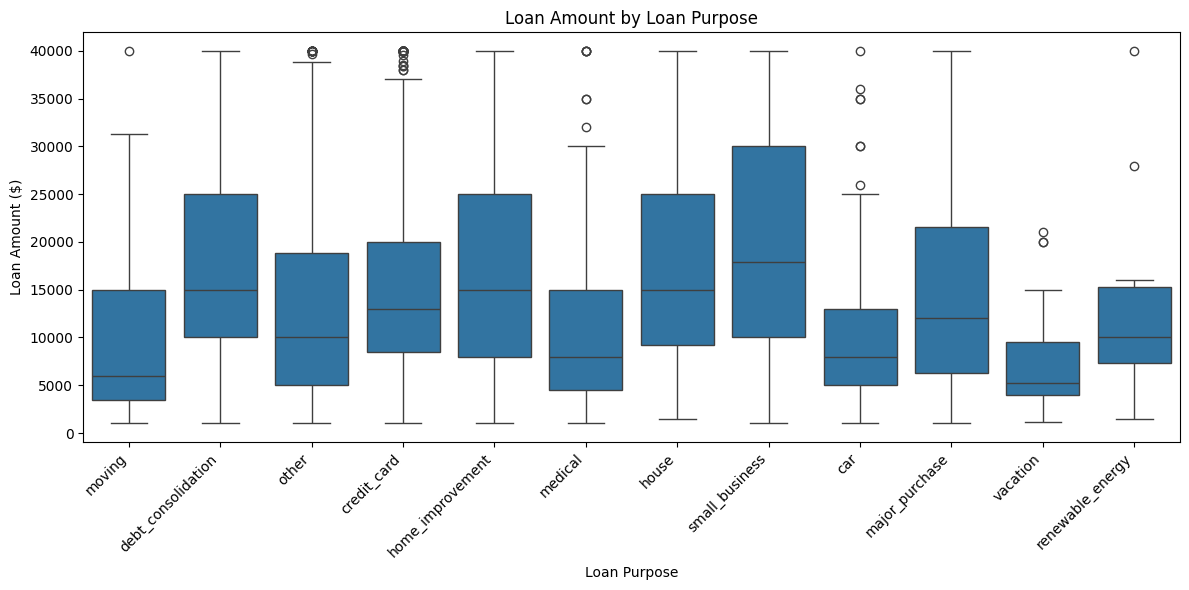

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='loan_purpose',
    y='loan_amount'
)

plt.title('Loan Amount by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Loan Amount ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

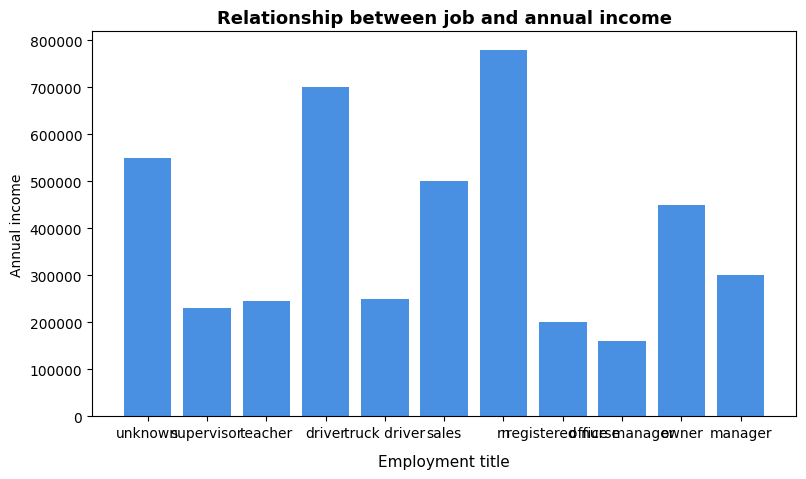

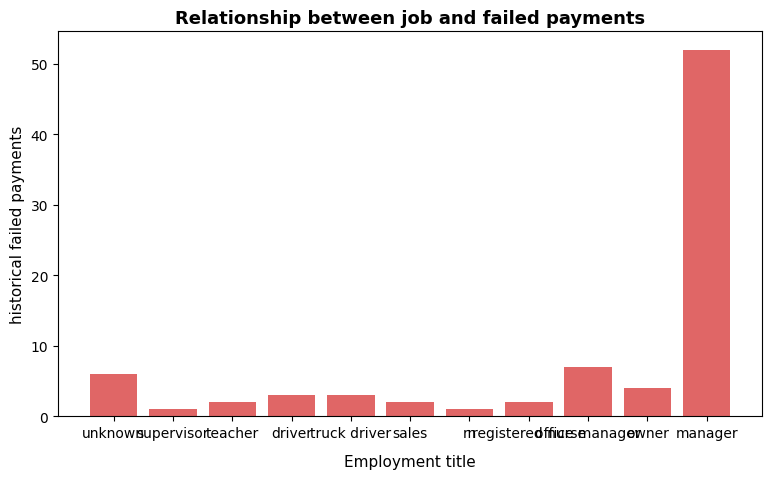

In [84]:
top_10_titles = df['emp_title'].value_counts().head(11).index
df_filtered = df[df['emp_title'].isin(top_10_titles)]
plt.figure(figsize=(20, 5))
plt.subplot(1,2,1)
plt.bar(df_filtered['emp_title'], df_filtered['annual_income'], color='#4a90e2')

plt.title('Relationship between job and annual income', fontsize=13, fontweight='bold')
plt.xlabel('Employment title', fontsize=11, labelpad=10)
plt.ylabel('Annual income', fontsize=10)

plt.figure(figsize=(20, 5))
plt.subplot(1,2,2)
plt.bar(df_filtered['emp_title'], df_filtered['num_historical_failed_to_pay'], color='#e06666')

plt.title('Relationship between job and failed payments', fontsize=13, fontweight='bold')
plt.xlabel('Employment title', fontsize=11, labelpad=10)
plt.ylabel('historical failed payments', fontsize=11)

plt.show()

i'd like to connect my hypothesis test to my research question and see which occupations are tied to which loan purpose, and then tie that back to reliability with their historical failed payments.

In [85]:
import pandas as pd

completed = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

In [86]:
table = pd.crosstab(
    completed["loan_purpose"],
    completed["loan_status"]
)

print(table)


loan_status         Charged Off  Fully Paid
loan_purpose                               
car                           0           6
credit_card                   1          70
debt_consolidation            2         224
home_improvement              2          33
house                         1           5
major_purchase                0          18
medical                       0          15
moving                        0           6
other                         1          59
small_business                0           6
vacation                      0           5


In [87]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

Chi-square Statistic: 14.5890574205909
Degrees of Freedom: 10
P-value: 0.14777773316896464


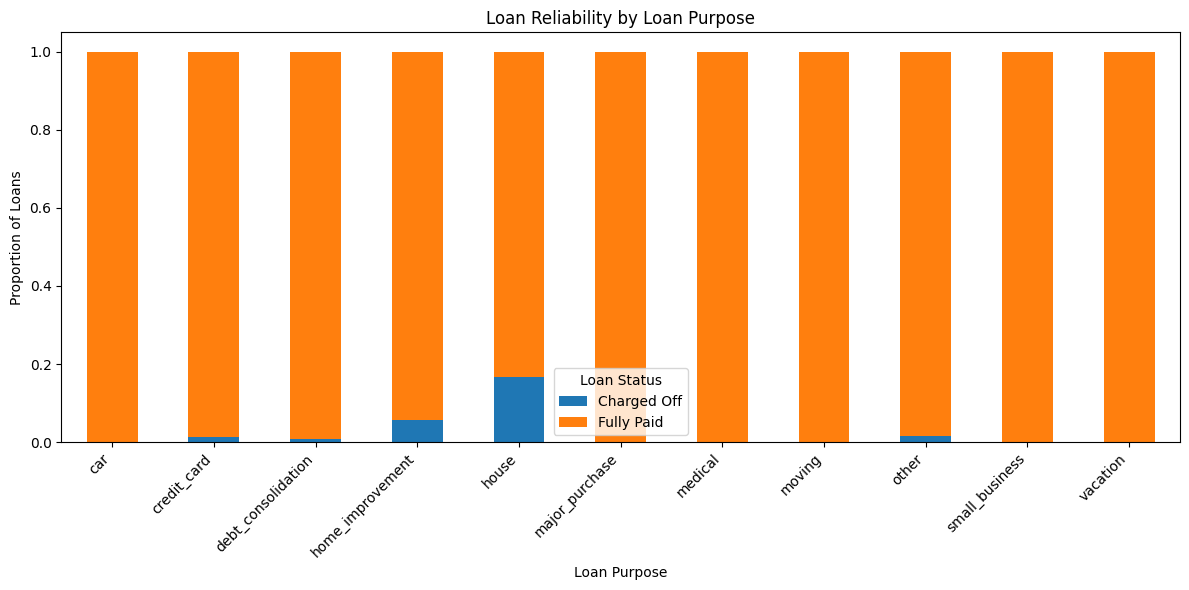

In [90]:
import matplotlib.pyplot as plt

proportions = table.div(table.sum(axis=1), axis=0)

proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Loan Reliability by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Proportion of Loans")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()